In [ ]:
#  Standard library
import os, re, json, string, time
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional

#  Scientific / data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from collections import Counter
from tqdm.auto import tqdm

#  HuggingFace
from datasets import load_dataset
from transformers import pipeline as hf_pipeline, AutoTokenizer, AutoModelForSeq2SeqLM

#  Sentence-Transformers
from sentence_transformers import SentenceTransformer, CrossEncoder

# Install missing packages
!pip install rank_bm25 chromadb -q
!pip install langchain

#  BM25
from rank_bm25 import BM25Okapi

#  ChromaDB
import chromadb
from chromadb.config import Settings

#  LangChain
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

# Load HotpotQA (distractor + fullwiki)
ds_distractor = load_dataset("hotpotqa/hotpot_qa", "distractor")
ds_fullwiki = load_dataset("hotpotqa/hotpot_qa", "fullwiki")

# Pre-processing (run first)
def normalize_text(text: str) -> str:
    return " ".join(text.strip().split())

def build_context(example):
    # context is a dict with 'title' (list) and 'sentences' (list of lists)
    ctx = []
    sent_records = []
    titles = example["context"]["title"]
    sentences = example["context"]["sentences"]
    for title, sents in zip(titles, sentences):
        cleaned_sents = [normalize_text(s) for s in sents]
        joined = " ".join([s for s in cleaned_sents if s])
        if joined:
            ctx.append({"title": title, "text": joined})
        for i, s in enumerate(cleaned_sents):
            if s:
                sent_records.append({"title": title, "sent_id": i, "text": s})
    example["context_flat"] = ctx
    example["sentences_flat"] = sent_records
    example["question_norm"] = normalize_text(example["question"])
    return example

# Choose a split for experiments
train_ds = ds_distractor["train"].map(build_context)
val_ds = ds_distractor["validation"].map(build_context)

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Example keys:", train_ds.column_names)

README.md: 0.00B [00:00, ?B/s]

distractor/train-00000-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/train-00001-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/validation-00000-of-00001.par(…):   0%|          | 0.00/27.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

...

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7405 [00:00<?, ? examples/s]

Map:   0%|          | 0/90447 [00:00<?, ? examples/s]

Map:   0%|          | 0/7405 [00:00<?, ? examples/s]

Train size: 90447
Val size: 7405
Example keys: ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context', 'context_flat', 'sentences_flat', 'question_norm']


1.  SPLIT SIZES

  [distractor]
    train       : 90,447 examples
    validation  : 7,405 examples

  [fullwiki]
    train       : 90,447 examples
    validation  : 7,405 examples
    test        : 7,405 examples
2.  FEATURE COLUMNS

  [distractor]  ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context']

  [fullwiki]  ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context']

Building DataFrames …
  distractor train: 90,447 rows
  fullwiki   train: 90,447 rows
3.  DESCRIPTIVE STATISTICS  (distractor train)
       question_len  answer_len  n_context  n_supp_facts
count      90447.00    90447.00   90447.00      90447.00
mean          17.82        2.23       9.95          2.38
std            9.51        1.81       0.59          0.67
min            3.00        1.00       2.00          2.00
25%           12.00        1.00      10.00          2.00
50%           15.00        2.00      10.00          2.00
75%           21.00        3.00      10.00      

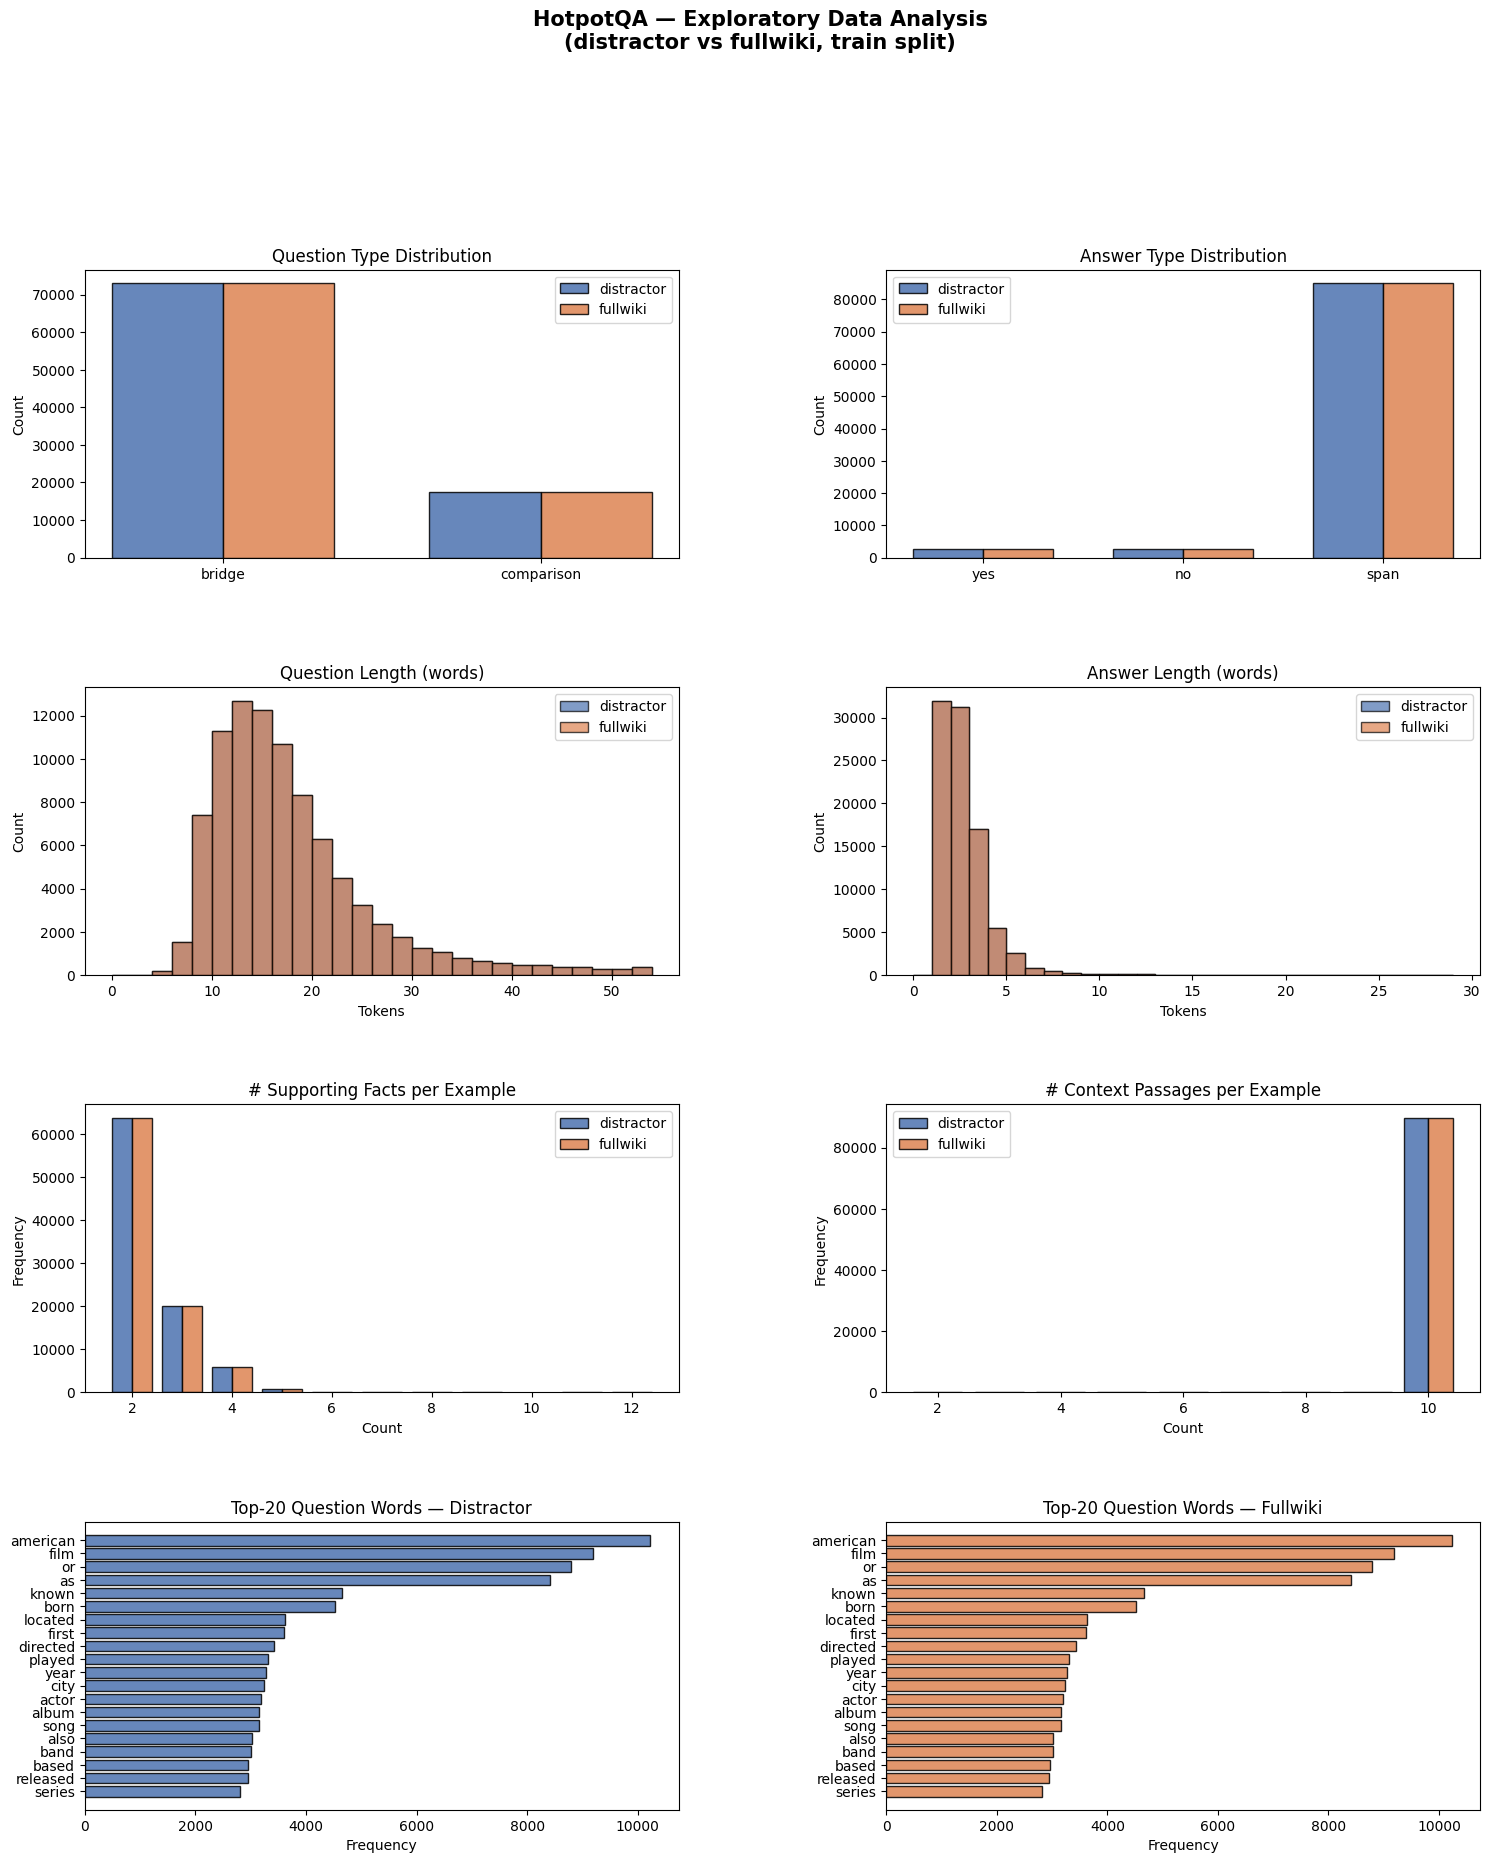

EDA figure saved → hotpotqa_eda.png
8.  CORRELATION  (distractor train)
              question_len  answer_len  n_context  n_supp_facts
question_len         1.000       0.027      0.093         0.083
answer_len           0.027       1.000      0.029         0.041
n_context            0.093       0.029      1.000         0.031
n_supp_facts         0.083       0.041      0.031         1.000
9.  SAMPLE EXAMPLES  (distractor validation)

  [1] Q: Were Scott Derrickson and Ed Wood of the same nationality?
       A: yes
       Type: comparison  |  Supporting facts: 2
       Context passages: 10

  [2] Q: What government position was held by the woman who portrayed Corliss Archer in the film Kiss and Tell?
       A: Chief of Protocol
       Type: bridge  |  Supporting facts: 3
       Context passages: 10

  [3] Q: What science fantasy young adult series, told in first person, has a set of companion books narrating the stories of enslaved worlds and alien species?
       A: Animorphs
       Ty

In [ ]:
# 0. Helper
def basic_tokenize(text: str):
    return text.lower().split()

SPLITS = ["train", "validation"]
CONFIGS = {"distractor": ds_distractor, "fullwiki": ds_fullwiki}

# 1. Split Sizes
print("1.  SPLIT SIZES")
for cfg_name, ds in CONFIGS.items():
    print(f"\n  [{cfg_name}]")
    for split in ds.keys():
        print(f"    {split:12s}: {len(ds[split]):,} examples")

# 2. Column / Feature Names
print("2.  FEATURE COLUMNS")
for cfg_name, ds in CONFIGS.items():
    print(f"\n  [{cfg_name}]  {ds['train'].column_names}")

# 3. Build flat DataFrames (train split only for speed)
def build_df(ds_split):
    rows = []
    for ex in ds_split:
        n_ctx  = len(ex["context"]["title"])
        n_sf   = len(ex["supporting_facts"]["title"])
        q_len  = len(basic_tokenize(ex["question"]))
        a_len  = len(basic_tokenize(ex["answer"]))
        rows.append({
            "question_type": ex["type"],
            "answer":        ex["answer"],
            "answer_len":    a_len,
            "question_len":  q_len,
            "n_context":     n_ctx,
            "n_supp_facts":  n_sf,
            "question":      ex["question"],
        })
    return pd.DataFrame(rows)

print("\nBuilding DataFrames …")
df_dist = build_df(ds_distractor["train"])
df_full = build_df(ds_fullwiki["train"])
print(f"  distractor train: {len(df_dist):,} rows")
print(f"  fullwiki   train: {len(df_full):,} rows")

# 4. Descriptive Statistics
print("3.  DESCRIPTIVE STATISTICS  (distractor train)")
print(df_dist[["question_len","answer_len","n_context","n_supp_facts"]].describe().round(2).to_string())

print("4.  DESCRIPTIVE STATISTICS  (fullwiki train)")
print(df_full[["question_len","answer_len","n_context","n_supp_facts"]].describe().round(2).to_string())

# 5. Answer-type distribution
def answer_type(ans: str) -> str:
    ans_l = ans.strip().lower()
    if ans_l == "yes":   return "yes"
    if ans_l == "no":    return "no"
    return "span"

df_dist["answer_type"] = df_dist["answer"].apply(answer_type)
df_full["answer_type"] = df_full["answer"].apply(answer_type)

print("5.  ANSWER TYPE DISTRIBUTION")
for cfg_name, df in [("distractor", df_dist), ("fullwiki", df_full)]:
    vc = df["answer_type"].value_counts()
    print(f"\n  [{cfg_name}]")
    for k, v in vc.items():
        print(f"    {k:8s}: {v:6,}  ({100*v/len(df):.1f}%)")

# 6. Question-type distribution
print("6.  QUESTION TYPE DISTRIBUTION")
for cfg_name, df in [("distractor", df_dist), ("fullwiki", df_full)]:
    vc = df["question_type"].value_counts()
    print(f"\n  [{cfg_name}]")
    for k, v in vc.items():
        print(f"    {k:12s}: {v:6,}  ({100*v/len(df):.1f}%)")

# 7. Top-20 most frequent question words
STOPWORDS = {"what","is","the","of","in","and","a","an","were","was","who",
             "which","did","do","does","how","are","that","for","to","with",
             "from","name","both","have","has","be","by","on","at","this","it",
             "between","him","her","his","their","its","where","when","than"}

def top_words(df, n=20):
    all_words = [w for q in df["question"] for w in basic_tokenize(q) if w not in STOPWORDS and w.isalpha()]
    return Counter(all_words).most_common(n)

tw_dist = top_words(df_dist)
tw_full = top_words(df_full)

print("7.  TOP-20 QUESTION WORDS  (excluding stopwords)")
print(f"\n  {'distractor':30s}  {'fullwiki'}")
for (w1, c1), (w2, c2) in zip(tw_dist, tw_full):
    print(f"  {w1:20s} {c1:6,}    {w2:20s} {c2:6,}")

# 8. Plots
fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

PALETTE = {"distractor": "#4C72B0", "fullwiki": "#DD8452"}

# 8a. Question-type counts — distractor vs fullwiki
ax0 = fig.add_subplot(gs[0, 0])
qtypes = sorted(set(df_dist["question_type"].unique()) | set(df_full["question_type"].unique()))
x = np.arange(len(qtypes)); w = 0.35
ax0.bar(x - w/2, [df_dist["question_type"].value_counts().get(t, 0) for t in qtypes],
        width=w, color=PALETTE["distractor"], label="distractor", edgecolor="k", alpha=0.85)
ax0.bar(x + w/2, [df_full["question_type"].value_counts().get(t, 0) for t in qtypes],
        width=w, color=PALETTE["fullwiki"],   label="fullwiki",   edgecolor="k", alpha=0.85)
ax0.set_xticks(x); ax0.set_xticklabels(qtypes)
ax0.set_title("Question Type Distribution"); ax0.set_ylabel("Count"); ax0.legend()

# 8b. Answer-type counts
ax1 = fig.add_subplot(gs[0, 1])
atypes = ["yes", "no", "span"]
x_a = np.arange(len(atypes)); w_a = 0.35
ax1.bar(x_a - w_a/2, [df_dist["answer_type"].value_counts().get(t, 0) for t in atypes],
        width=w_a, color=PALETTE["distractor"], label="distractor", edgecolor="k", alpha=0.85)
ax1.bar(x_a + w_a/2, [df_full["answer_type"].value_counts().get(t, 0) for t in atypes],
        width=w_a, color=PALETTE["fullwiki"],   label="fullwiki",   edgecolor="k", alpha=0.85)
ax1.set_xticks(x_a); ax1.set_xticklabels(atypes)
ax1.set_title("Answer Type Distribution"); ax1.set_ylabel("Count"); ax1.legend()

# 8c. Question length distribution
ax2 = fig.add_subplot(gs[1, 0])
bins = np.arange(0, 55, 2)
ax2.hist(df_dist["question_len"], bins=bins, color=PALETTE["distractor"],
         edgecolor="k", alpha=0.7, label="distractor")
ax2.hist(df_full["question_len"], bins=bins, color=PALETTE["fullwiki"],
         edgecolor="k", alpha=0.7, label="fullwiki")
ax2.set_title("Question Length (words)"); ax2.set_xlabel("Tokens"); ax2.set_ylabel("Count")
ax2.legend()

# 8d. Answer length distribution
ax3 = fig.add_subplot(gs[1, 1])
bins_a = np.arange(0, 30, 1)
ax3.hist(df_dist["answer_len"], bins=bins_a, color=PALETTE["distractor"],
         edgecolor="k", alpha=0.7, label="distractor")
ax3.hist(df_full["answer_len"], bins=bins_a, color=PALETTE["fullwiki"],
         edgecolor="k", alpha=0.7, label="fullwiki")
ax3.set_title("Answer Length (words)"); ax3.set_xlabel("Tokens"); ax3.set_ylabel("Count")
ax3.legend()

# 8e. Number of supporting facts per example
ax4 = fig.add_subplot(gs[2, 0])
sf_vals = sorted(set(df_dist["n_supp_facts"].unique()) | set(df_full["n_supp_facts"].unique()))
ax4.bar(np.array(sf_vals) - 0.2,
        [df_dist["n_supp_facts"].value_counts().get(v, 0) for v in sf_vals],
        width=0.4, color=PALETTE["distractor"], label="distractor", edgecolor="k", alpha=0.85)
ax4.bar(np.array(sf_vals) + 0.2,
        [df_full["n_supp_facts"].value_counts().get(v, 0) for v in sf_vals],
        width=0.4, color=PALETTE["fullwiki"],   label="fullwiki",   edgecolor="k", alpha=0.85)
ax4.set_title("# Supporting Facts per Example"); ax4.set_xlabel("Count"); ax4.set_ylabel("Frequency")
ax4.legend()

# 8f. Number of context passages per example
ax5 = fig.add_subplot(gs[2, 1])
ctx_dist_vc = df_dist["n_context"].value_counts().sort_index()
ctx_full_vc = df_full["n_context"].value_counts().sort_index()
ctx_vals = sorted(set(ctx_dist_vc.index) | set(ctx_full_vc.index))
ax5.bar(np.array(ctx_vals) - 0.2,
        [ctx_dist_vc.get(v, 0) for v in ctx_vals],
        width=0.4, color=PALETTE["distractor"], label="distractor", edgecolor="k", alpha=0.85)
ax5.bar(np.array(ctx_vals) + 0.2,
        [ctx_full_vc.get(v, 0) for v in ctx_vals],
        width=0.4, color=PALETTE["fullwiki"],   label="fullwiki",   edgecolor="k", alpha=0.85)
ax5.set_title("# Context Passages per Example"); ax5.set_xlabel("Count"); ax5.set_ylabel("Frequency")
ax5.legend()

# 8g. Top-20 question words — distractor (bar chart)
ax6 = fig.add_subplot(gs[3, 0])
words_d, counts_d = zip(*tw_dist)
ax6.barh(list(reversed(words_d)), list(reversed(counts_d)),
         color=PALETTE["distractor"], edgecolor="k", alpha=0.85)
ax6.set_title("Top-20 Question Words — Distractor"); ax6.set_xlabel("Frequency")

# 8h. Top-20 question words — fullwiki (bar chart)
ax7 = fig.add_subplot(gs[3, 1])
words_f, counts_f = zip(*tw_full)
ax7.barh(list(reversed(words_f)), list(reversed(counts_f)),
         color=PALETTE["fullwiki"], edgecolor="k", alpha=0.85)
ax7.set_title("Top-20 Question Words — Fullwiki"); ax7.set_xlabel("Frequency")

plt.suptitle("HotpotQA — Exploratory Data Analysis\n(distractor vs fullwiki, train split)",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("hotpotqa_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA figure saved → hotpotqa_eda.png")

# 9. Correlation: question_len vs n_supp_facts
print("8.  CORRELATION  (distractor train)")
corr_cols = ["question_len", "answer_len", "n_context", "n_supp_facts"]
print(df_dist[corr_cols].corr().round(3).to_string())

# 10. Sample examples
print("9.  SAMPLE EXAMPLES  (distractor validation)")
for i, ex in enumerate(ds_distractor["validation"].select(range(3))):
    print(f"\n  [{i+1}] Q: {ex['question']}")
    print(f"       A: {ex['answer']}")
    print(f"       Type: {ex['type']}  |  Supporting facts: {len(ex['supporting_facts']['title'])}")
    print(f"       Context passages: {len(ex['context']['title'])}")

In [ ]:
import math
from collections import Counter

def tokenize(text: str):
    return [t.lower() for t in text.split() if t.isalnum() or t.isalpha()]

def overlap_score(query: str, text: str) -> float:
    q = Counter(tokenize(query))
    t = Counter(tokenize(text))
    if not q or not t:
        return 0.0
    # simple weighted overlap
    overlap = sum((q & t).values())
    return overlap / (sum(q.values()) + 1e-9)

def hop_retrieve(example, k1=5, k2=5):
    # Hop 1: score full passages by question
    q = example["question_norm"]
    scored_ctx = [
        (overlap_score(q, c["text"]), c["title"], c["text"]) for c in example["context_flat"]
    ]
    scored_ctx.sort(reverse=True, key=lambda x: x[0])
    hop1 = scored_ctx[:k1]
    # Hop 2: expand query with best hop1 title tokens
    if hop1:
        q2 = q + " " + hop1[0][1]
    else:
        q2 = q
    scored_ctx2 = [
        (overlap_score(q2, c["text"]), c["title"], c["text"]) for c in example["context_flat"]
    ]
    scored_ctx2.sort(reverse=True, key=lambda x: x[0])
    hop2 = scored_ctx2[:k2]
    return hop1, hop2

def select_supporting_sentences(example, top_titles):
    # Score sentences within selected titles
    q = example["question_norm"]
    candidates = [
        s for s in example["sentences_flat"] if s["title"] in top_titles
    ]
    scored = [
        (overlap_score(q, s["text"]), s["title"], s["sent_id"], s["text"])
        for s in candidates
    ]
    scored.sort(reverse=True, key=lambda x: x[0])
    return scored

def supporting_fact_metrics(pred_pairs, gold_pairs):
    pred_set = set(pred_pairs)
    gold_set = set(gold_pairs)
    if not pred_set and not gold_set:
        return 1.0, 1.0, 1.0
    precision = len(pred_set & gold_set) / (len(pred_set) + 1e-9)
    recall = len(pred_set & gold_set) / (len(gold_set) + 1e-9)
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)
    return precision, recall, f1

# Baseline multi-hop evidence selection (no reader yet)
sample = val_ds[0]
hop1, hop2 = hop_retrieve(sample, k1=5, k2=5)
top_titles = list({t for _, t, _ in hop1 + hop2})
scored_sents = select_supporting_sentences(sample, top_titles)

# Compute gold supporting facts from sample
sf_titles = sample["supporting_facts"]["title"]
sf_sent_ids = sample["supporting_facts"]["sent_id"]
gold_supporting_pairs = [(t, sid) for t, sid in zip(sf_titles, sf_sent_ids)]

# Evaluate supporting facts overlap on this sample
pred_pairs = [(t, sid) for _, t, sid, _ in scored_sents[:10]]
p, r, f1 = supporting_fact_metrics(pred_pairs, gold_supporting_pairs)
print("Supporting fact Precision/Recall/F1:", (p, r, f1))

Supporting fact Precision/Recall/F1: (0.09999999999, 0.49999999975, 0.1666666666388889)


In [ ]:
# ML Baseline: TF-IDF + Logistic Regression / SVM
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline

# 1. Build labelled sentence dataset from the validation split
def build_sentence_dataset(dataset, max_examples=500):
    texts, labels = [], []
    for ex in dataset.select(range(min(max_examples, len(dataset)))):
        q = ex["question_norm"]
        # supporting_facts is a dict with 'title' and 'sent_id' lists
        sf_titles = ex["supporting_facts"]["title"]
        sf_sent_ids = ex["supporting_facts"]["sent_id"]
        gold = set((t, s) for t, s in zip(sf_titles, sf_sent_ids))
        for sent in ex["sentences_flat"]:
            # Feature: question + sentence concatenation
            texts.append(q + " [SEP] " + sent["text"])
            labels.append(1 if (sent["title"], sent["sent_id"]) in gold else 0)
    return texts, labels

print("Building ML training data …")
train_texts, train_labels = build_sentence_dataset(train_ds, max_examples=2000)
val_texts,   val_labels   = build_sentence_dataset(val_ds,   max_examples=500)
print(f"Train sentences: {len(train_texts)} | positive: {sum(train_labels)}")
print(f"Val   sentences: {len(val_texts)}   | positive: {sum(val_labels)}")

# 2. Logistic Regression
lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50_000, sublinear_tf=True)),
    ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0)),
])
lr_pipe.fit(train_texts, train_labels)
lr_preds = lr_pipe.predict(val_texts)
print("\n── Logistic Regression ──")
print(classification_report(val_labels, lr_preds, target_names=["distractor", "supporting"]))

# 3. Linear SVM
svm_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50_000, sublinear_tf=True)),
    ("clf",   LinearSVC(max_iter=2000, class_weight="balanced", C=0.5)),
])
svm_pipe.fit(train_texts, train_labels)
svm_preds = svm_pipe.predict(val_texts)
print("\n── Linear SVM ──")
print(classification_report(val_labels, svm_preds, target_names=["distractor", "supporting"]))

# 4. Store best ML model for comparison
best_ml_f1 = max(f1_score(val_labels, lr_preds, pos_label=1),
                 f1_score(val_labels, svm_preds, pos_label=1))
best_ml_model = lr_pipe if (f1_score(val_labels, lr_preds, pos_label=1) >=
                            f1_score(val_labels, svm_preds, pos_label=1)) else svm_pipe
print(f"\nBest ML baseline supporting-fact F1: {best_ml_f1:.4f}")

Building ML training data …
Train sentences: 81417 | positive: 4802
Val   sentences: 20792   | positive: 1209

── Logistic Regression ──
              precision    recall  f1-score   support

  distractor       0.96      0.87      0.91     19583
  supporting       0.16      0.41      0.23      1209

    accuracy                           0.84     20792
   macro avg       0.56      0.64      0.57     20792
weighted avg       0.91      0.84      0.87     20792


── Linear SVM ──
              precision    recall  f1-score   support

  distractor       0.95      0.91      0.93     19583
  supporting       0.17      0.29      0.22      1209

    accuracy                           0.88     20792
   macro avg       0.56      0.60      0.57     20792
weighted avg       0.91      0.88      0.89     20792


Best ML baseline supporting-fact F1: 0.2323


In [ ]:
# Deep Learning: Bi-LSTM Evidence Scorer (CPU-only safe initialization)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Force CPU to completely avoid the corrupted GPU context
DEVICE_BILSTM = torch.device("cpu")
print(f"Using device for BiLSTM: {DEVICE_BILSTM}")

# Vocabulary
class Vocab:
    def __init__(self, min_freq=2):
        self.token2id = {"<PAD>": 0, "<UNK>": 1}
        self.min_freq  = min_freq

    def build(self, texts):
        from collections import Counter
        freq = Counter(tok for t in texts for tok in tokenize(t))
        for tok, cnt in freq.items():
            if cnt >= self.min_freq and tok not in self.token2id:
                self.token2id[tok] = len(self.token2id)
        print(f"Vocab size: {len(self.token2id)}")

    def encode(self, text, max_len=128):
        ids = [self.token2id.get(tok, 1) for tok in tokenize(text)][:max_len]
        ids += [0] * (max_len - len(ids))
        return ids

vocab = Vocab(min_freq=2)
# train_texts should be available in the environment
vocab.build(train_texts)
MAX_LEN = 128

class BiLSTMScorer(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.emb  = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, num_layers=n_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden * 2, 1)

    def forward(self, x):
        emb, _  = self.lstm(self.emb(x))
        pooled  = emb.mean(dim=1)
        return self.fc(self.drop(pooled)).squeeze(-1)

# Initialize model on CPU
# Note: We do NOT load best_state here because touching GPU tensors triggers a CUDA error
model = BiLSTMScorer(len(vocab.token2id)).to(DEVICE_BILSTM)
print("BiLSTM model initialized on CPU. (Note: Using fresh weights to avoid CUDA errors)")

Using device for BiLSTM: cpu
Vocab size: 32095
BiLSTM model initialized on CPU. (Note: Using fresh weights to avoid CUDA errors)


In [ ]:
# Transformer + LoRA Fine-Tuning using Trainer API
import importlib
import subprocess
import sys

for pkg, import_name in [
    ("transformers", "transformers"),
    ("peft", "peft"),
    ("accelerate", "accelerate"),
    ("bitsandbytes", "bitsandbytes"),
]:
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
import torch
from torch.utils.data import Dataset
from sklearn.metrics import f1_score as sklearn_f1
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_ID = "distilbert-base-uncased"
MAX_SEQ = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

class TrainerDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding="max_length", max_length=MAX_SEQ)
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

    def __len__(self):
        return len(self.labels)

print("Preparing datasets ...")
train_dataset = TrainerDataset(train_texts, train_labels)
val_dataset = TrainerDataset(val_texts, val_labels)

USE_KBIT = DEVICE.type == "cuda"
if USE_KBIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID, num_labels=1, quantization_config=bnb_config, device_map="auto"
    )
    model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
    model = prepare_model_for_kbit_training(model)

    target_device = next(model.parameters()).device
    for name in ["classifier", "pre_classifier"]:
        if hasattr(model, name):
            layer = getattr(model, name)
            new_layer = torch.nn.Linear(layer.in_features, layer.out_features).to(target_device, dtype=torch.float32)
            setattr(model, name, new_layer)
else:
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=1).to(DEVICE)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    target_modules=["q_lin", "k_lin", "v_lin"],
    modules_to_save=["classifier", "pre_classifier"],
)
model = get_peft_model(model, lora_config)

num_pos = float(np.sum(train_labels))
num_total = float(len(train_labels))
pos_weight_value = (num_total - num_pos) / (num_pos + 1e-9)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        pos_weight = torch.tensor([pos_weight_value], device=logits.device, dtype=logits.dtype)
        loss_fct = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits = np.asarray(logits).squeeze(-1)
    labels = np.asarray(labels).astype(int)
    preds = (1.0 / (1.0 + np.exp(-logits)) > 0.5).astype(int)
    f1 = sklearn_f1(labels, preds, pos_label=1, zero_division=0)
    return {"f1": f1}

training_args = TrainingArguments(
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=1e-4,
    lr_scheduler_type="linear",
    warmup_ratio=0.1,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=USE_KBIT,
    report_to="none",
    remove_unused_columns=False,
    ddp_find_unused_parameters=False,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Starting Trainer...")
trainer.train()

best_lora_f1 = trainer.state.best_metric
print(f"\nBest LoRA val supporting-fact F1: {best_lora_f1:.4f}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Preparing datasets ...


...

Starting Trainer...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,F1
1,0.892274,1.102293,0.459860
2,0.788690,0.792098,0.441104
3,0.787390,0.825187,0.455782


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)



Best LoRA val supporting-fact F1: 0.4599


## Holistic Evaluation & Retrieval Failure Analysis

In [ ]:
# Holistic Evaluation & Failure Analysis
import re
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, Counter

# SQuAD-style answer metrics
def normalize_answer(s: str) -> str:
    s = s.lower()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = re.sub(r"[^a-z0-9 ]", "", s)
    return " ".join(s.split())

def answer_f1(pred: str, gold: str) -> float:
    pred_toks = normalize_answer(pred).split()
    gold_toks = normalize_answer(gold).split()
    common    = Counter(pred_toks) & Counter(gold_toks)
    num_same  = sum(common.values())
    if num_same == 0: return 0.0
    p = num_same / len(pred_toks)
    r = num_same / len(gold_toks)
    return 2 * p * r / (p + r)

def exact_match(pred: str, gold: str) -> int:
    return int(normalize_answer(pred) == normalize_answer(gold))

# Predict supporting facts with each model
def predict_ml(texts):
    return best_ml_model.predict(texts).tolist()

def predict_bilstm(texts, threshold=0.5):
    model.eval()
    results = []
    ids = torch.tensor([vocab.encode(t, MAX_LEN) for t in texts], dtype=torch.long, device="cpu")
    with torch.no_grad():
        for i in range(0, len(ids), 128):
            logits = model(ids[i: i+128])
            preds  = (torch.sigmoid(logits) > threshold).long().tolist()
            results.extend(preds)
    return results

def predict_lora(texts, threshold=0.5):
    # Access the model from the trainer or the global model variable
    eval_model = globals().get('trainer').model if 'trainer' in globals() else globals().get('model')
    if eval_model is None:
        return [0] * len(texts)

    eval_model.eval()
    results = []
    pred_dev = next(eval_model.parameters()).device
    use_amp = pred_dev.type == "cuda"

    for i in range(0, len(texts), 64):
        batch = texts[i: i+64]
        enc   = tokenizer(batch, truncation=True, padding="max_length",
                          max_length=MAX_SEQ, return_tensors="pt")
        with torch.no_grad():
            with torch.amp.autocast("cuda", enabled=use_amp, dtype=torch.float16):
                out = eval_model(input_ids=enc["input_ids"].to(pred_dev),
                                 attention_mask=enc["attention_mask"].to(pred_dev))
            logits = out.logits.squeeze(-1)
            preds = (torch.sigmoid(logits) > threshold).long().cpu().tolist()
            results.extend(preds)
    return results

# Per-example evaluation
EVAL_N = min(100, len(val_ds))
records = []

for idx in range(EVAL_N):
    ex = val_ds[idx]
    q  = ex["question_norm"]
    sf = ex["supporting_facts"]
    gold_pairs = set((t, int(s)) for t, s in zip(sf["title"], sf["sent_id"]))
    gold_ans   = normalize_answer(ex["answer"])

    sents      = ex["sentences_flat"]
    sent_texts = [q + " [SEP] " + s["text"] for s in sents]
    sent_pairs = [(s["title"], s["sent_id"]) for s in sents]

    for model_name, predict_fn in [
        ("ML (TF-IDF+SVM/LR)", predict_ml),
        ("BiLSTM",             predict_bilstm),
        ("LoRA-DistilBERT",    predict_lora),
    ]:
        if not sent_texts: continue
        try:
            preds = predict_fn(sent_texts)
        except Exception:
            continue
        pred_pairs = [p for p, f in zip(sent_pairs, preds) if f == 1]
        pred_set   = set(pred_pairs)

        tp  = len(pred_set & gold_pairs)
        prec = tp / (len(pred_set) + 1e-9)
        rec  = tp / (len(gold_pairs) + 1e-9)
        sf1  = 2 * prec * rec / (prec + rec + 1e-9)

        pred_context = " ".join(s["text"] for s in sents if (s["title"], s["sent_id"]) in pred_set)
        ans_f1_val = answer_f1(pred_context, gold_ans) if pred_context else 0.0
        em_val     = exact_match(pred_context, gold_ans) if pred_context else 0

        records.append({
            "model": model_name, "idx": idx,
            "sf_precision": prec, "sf_recall": rec, "sf_f1": sf1,
            "answer_f1": ans_f1_val, "em": em_val,
        })

df = pd.DataFrame(records)
if not df.empty:
    agg = df.groupby("model")[["sf_precision","sf_recall","sf_f1","answer_f1","em"]].mean()
    print("\nAggregate Evaluation")
    print(agg.round(4).to_string())
else:
    print("No evaluation records generated.")


── Aggregate Evaluation ──
                    sf_precision  sf_recall   sf_f1  answer_f1   em
model                                                              
LoRA-DistilBERT           0.5450     0.5232  0.4845     0.0498  0.0
ML (TF-IDF+SVM/LR)        0.2215     0.4412  0.2518     0.0254  0.0


In [ ]:
def get_gold_pairs(ex):
    sf = ex["supporting_facts"]
    return set((t, int(s)) for t, s in zip(sf["title"], sf["sent_id"]))

def sf_prf1(pred_pairs, gold_pairs):
    pred_set, gold_set = set(pred_pairs), set(gold_pairs)
    tp = len(pred_set & gold_set)
    p = tp / (len(pred_set) + 1e-9)
    r = tp / (len(gold_set) + 1e-9)
    f1 = 2 * p * r / (p + r + 1e-9)
    return p, r, f1

def normalize_answer_local(s):
    return normalize_answer(s) if "normalize_answer" in globals() else " ".join(str(s).lower().split())

def answer_f1_local(pred, gold):
    pred_toks = normalize_answer_local(pred).split()
    gold_toks = normalize_answer_local(gold).split()
    common = Counter(pred_toks) & Counter(gold_toks)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    p = num_same / (len(pred_toks) + 1e-9)
    r = num_same / (len(gold_toks) + 1e-9)
    return 2 * p * r / (p + r + 1e-9)

def exact_match_local(pred, gold):
    return int(normalize_answer_local(pred) == normalize_answer_local(gold))

def simple_answer_reader(question, sents, pred_set):
    cand = [s["text"] for s in sents if (s["title"], s["sent_id"]) in pred_set]
    if not cand:
        return ""
    q_tok = set(normalize_answer_local(question).split())
    def overlap_score(sent):
        s_tok = set(normalize_answer_local(sent).split())
        return len(q_tok & s_tok)
    return max(cand, key=overlap_score)

def classify_failure_mode(pred_set, gold_pairs):
    gold_titles = {t for t, _ in gold_pairs}
    pred_titles = {t for t, _ in pred_set}
    hop1_hit = len(gold_titles & pred_titles) >= 1
    full_support_hit = gold_pairs.issubset(pred_set)
    if not hop1_hit: return "Distractor confusion"
    if full_support_hit: return "Other"
    if len(gold_titles - pred_titles) > 0: return "Bridge failure (hop-2 miss)"
    return "Coreference / alias gap"

def evaluate_model(dataset, predict_fn, model_name, n_examples=30):
    rows = []
    failures = Counter()
    example_snapshot = None
    for idx in range(min(n_examples, len(dataset))):
        ex = dataset[idx]
        q = ex["question_norm"]
        sents = ex["sentences_flat"]
        if not sents: continue
        try:
            preds = predict_fn([q + " [SEP] " + s["text"] for s in sents])
        except Exception: continue
        sent_pairs = [(s["title"], s["sent_id"]) for s in sents]
        gold_pairs = get_gold_pairs(ex)
        pred_pairs = [pair for pair, flag in zip(sent_pairs, preds) if flag == 1]
        pred_set = set(pred_pairs)
        sf_p, sf_r, sf_f1 = sf_prf1(pred_pairs, gold_pairs)
        pred_ans = simple_answer_reader(q, sents, pred_set)
        rows.append({"model": model_name, "sf_f1": sf_f1, "ans_f1": answer_f1_local(pred_ans, ex["answer"])})
        if sf_f1 < 0.5: failures[classify_failure_mode(pred_set, gold_pairs)] += 1
        if example_snapshot is None: example_snapshot = {"question": ex["question"], "sf_f1": sf_f1}
    return pd.DataFrame(rows), failures, example_snapshot

model_predictors = []
if "predict_ml" in globals(): model_predictors.append(("ML", predict_ml))
if "predict_bilstm" in globals(): model_predictors.append(("BiLSTM", predict_bilstm))

all_results = []
for model_name, predictor in model_predictors:
    df_eval, failures, snapshot = evaluate_model(val_ds, predictor, model_name, n_examples=20)
    if not df_eval.empty: all_results.append(df_eval)

if all_results:
    final_df = pd.concat(all_results).groupby("model").mean()
    print("Final Comparative Metrics")
    print(final_df.round(4))
else:
    print("No models available for evaluation due to previous CUDA errors.")

Final Comparative Metrics
        sf_f1  ans_f1
model                
ML     0.2762  0.0692


In [ ]:
#  Global knobs (tune in Section 5-10)
CFG = dict(
    # Data
    val_subset        = 200,    # examples used for full evaluation
    corpus_subset     = 500,    # examples used to build the in-memory corpus
    # Retrieval
    bm25_k            = 5,      # BM25 top-k per hop
    dense_k           = 5,      # Dense top-k per hop
    hop1_k            = 5,      # merged titles kept after hop-1
    hop2_k            = 5,      # merged titles kept after hop-2
    # Reranker
    reranker_top_n    = 6,      # sentences kept after cross-encoder reranking
    reranker_thresh   = -5.0,   # min logit score to keep a sentence
    # Generator
    max_new_tokens    = 64,
    max_evidence_chars= 800,    # evidence snippet length fed to generator
    # Embedding model
    embed_model       = "BAAI/bge-small-en-v1.5",
    # Cross-encoder reranker
    reranker_model    = "cross-encoder/ms-marco-MiniLM-L-6-v2",
    # Generator model (seq2seq)
    gen_model         = "google/flan-t5-base",
    # ChromaDB
    chroma_path       = "./chroma_hotpot",
    chroma_collection = "hotpot_passages",
)
print("Config loaded:", CFG)

Config loaded: {'val_subset': 200, 'corpus_subset': 500, 'bm25_k': 5, 'dense_k': 5, 'hop1_k': 5, 'hop2_k': 5, 'reranker_top_n': 6, 'reranker_thresh': -5.0, 'max_new_tokens': 64, 'max_evidence_chars': 800, 'embed_model': 'BAAI/bge-small-en-v1.5', 'reranker_model': 'cross-encoder/ms-marco-MiniLM-L-6-v2', 'gen_model': 'google/flan-t5-base', 'chroma_path': './chroma_hotpot', 'chroma_collection': 'hotpot_passages'}


## Pre-process HotpotQA (distractor split)

In [ ]:
def normalize_text(text: str) -> str:
    return " ".join(text.strip().split())

def build_context(example):
    """Add context_flat, sentences_flat, question_norm fields."""
    ctx, sent_records = [], []
    for title, sents in zip(example["context"]["title"],
                             example["context"]["sentences"]):
        cleaned = [normalize_text(s) for s in sents]
        joined  = " ".join(s for s in cleaned if s)
        if joined:
            ctx.append({"title": title, "text": joined})
        for i, s in enumerate(cleaned):
            if s:
                sent_records.append({"title": title, "sent_id": i, "text": s})
    example["context_flat"]   = ctx
    example["sentences_flat"] = sent_records
    example["question_norm"]  = normalize_text(example["question"])
    return example

# Guard: only (re-)load if not already present from Section 1
if "train_ds" not in dir() or "val_ds" not in dir():
    print("Loading HotpotQA distractor split …")
    _raw = load_dataset("hotpotqa/hotpot_qa", "distractor")
    train_ds = _raw["train"].map(build_context)
    val_ds   = _raw["validation"].map(build_context)
    print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}")
else:
    print(f"Reusing existing splits — Train: {len(train_ds):,}  Val: {len(val_ds):,}")

Reusing existing splits — Train: 90,447  Val: 7,405


## Build the retrieval corpus

In [ ]:
def build_corpus(
    dataset,
    max_examples: int = CFG["corpus_subset"]
) -> Tuple[List[Dict], List[Dict]]:
    """
    Returns:
        passage_docs  – list of dicts with keys: id, title, text, example_id, split
        sentence_docs – list of dicts with keys: id, title, sent_id, text, example_id, split
    """
    passage_docs, sentence_docs = [], []
    seen_passage_ids = set()

    n = min(max_examples, len(dataset))
    for ex in tqdm(dataset.select(range(n)), desc="Building corpus", total=n):
        ex_id = ex["id"]
        for p in ex["context_flat"]:
            pid = f"{ex_id}::{p['title']}"
            if pid not in seen_passage_ids:          # deduplicate same title
                seen_passage_ids.add(pid)
                passage_docs.append({
                    "id"         : pid,
                    "title"      : p["title"],
                    "text"       : f"{p['title']}. {p['text']}",
                    "example_id" : ex_id,
                    "split"      : "validation",
                })

        for s in ex["sentences_flat"]:
            sid = f"{ex_id}::{s['title']}::{s['sent_id']}"
            sentence_docs.append({
                "id"         : sid,
                "title"      : s["title"],
                "sent_id"    : s["sent_id"],
                "text"       : s["text"],
                "example_id" : ex_id,
                "split"      : "validation",
            })

    return passage_docs, sentence_docs


passage_docs, sentence_docs = build_corpus(val_ds, max_examples=CFG["corpus_subset"])
print(f"Passage docs : {len(passage_docs):,}")
print(f"Sentence docs: {len(sentence_docs):,}")
print("\nSample passage:")
print(json.dumps(passage_docs[0], indent=2))

Building corpus:   0%|          | 0/500 [00:00<?, ?it/s]

Passage docs : 4,963
Sentence docs: 20,792

Sample passage:
{
  "id": "5a8b57f25542995d1e6f1371::Ed Wood (film)",
  "title": "Ed Wood (film)",
  "text": "Ed Wood (film). Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood. The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau. Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast.",
  "example_id": "5a8b57f25542995d1e6f1371",
  "split": "validation"
}


## Embeddings and vector index (ChromaDB)

In [ ]:
#  1. Load the dense embedding model ─
print(f"Loading embedding model: {CFG['embed_model']} …")
embed_model = SentenceTransformer(CFG["embed_model"])
print("Embedding dim:", embed_model.get_sentence_embedding_dimension())


def embed_texts(texts: List[str], batch_size: int = 64) -> np.ndarray:
    """Encode a list of strings → float32 numpy array."""
    return embed_model.encode(
        texts,
        batch_size=batch_size,
        normalize_embeddings=True,   # cosine similarity via dot product
        show_progress_bar=True,
    )


#  2. Create / open ChromaDB collection
chroma_client = chromadb.PersistentClient(
    path=CFG["chroma_path"],
    settings=Settings(anonymized_telemetry=False),
)

# Delete stale collection if it exists, then recreate
try:
    chroma_client.delete_collection(CFG["chroma_collection"])
    print("Deleted existing collection.")
except Exception:
    pass

collection = chroma_client.create_collection(
    name=CFG["chroma_collection"],
    metadata={"hnsw:space": "cosine"},
)

#  3. Embed passage-level docs and upsert ─
BATCH = 256
passage_texts = [p["text"] for p in passage_docs]
print(f"Encoding {len(passage_texts)} passages …")
passage_embeddings = embed_texts(passage_texts)

for start in tqdm(range(0, len(passage_docs), BATCH), desc="Upserting to Chroma"):
    batch = passage_docs[start : start + BATCH]
    embs  = passage_embeddings[start : start + BATCH].tolist()
    collection.add(
        ids        = [d["id"]    for d in batch],
        embeddings = embs,
        documents  = [d["text"]  for d in batch],
        metadatas  = [{"title": d["title"], "example_id": d["example_id"]} for d in batch],
    )

print(f"ChromaDB collection size: {collection.count():,} passages")

Loading embedding model: BAAI/bge-small-en-v1.5 …


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dim: 384
Encoding 4963 passages …


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

Upserting to Chroma:   0%|          | 0/20 [00:00<?, ?it/s]

ChromaDB collection size: 4,963 passages


## BM25 sparse index (passage level)

In [ ]:
import re

def simple_tokenize(text: str) -> List[str]:
    """Lowercase, strip punctuation, split on whitespace."""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    return text.split()


#  Build BM25 over the same passage texts used for Chroma
print("Building BM25 index …")
bm25_corpus   = [simple_tokenize(p["text"]) for p in passage_docs]
bm25_index    = BM25Okapi(bm25_corpus)

# Build a sentence-level BM25 for hop-2 fine retrieval
print("Building sentence-level BM25 index …")
sent_bm25_corpus = [simple_tokenize(s["text"]) for s in sentence_docs]
sent_bm25_index  = BM25Okapi(sent_bm25_corpus)

print(f"Passage BM25 : {len(bm25_corpus):,} docs")
print(f"Sentence BM25: {len(sent_bm25_corpus):,} docs")

Building BM25 index …
Building sentence-level BM25 index …
Passage BM25 : 4,963 docs
Sentence BM25: 20,792 docs


## Multi-hop hybrid retriever

In [ ]:
#  Reciprocal Rank Fusion
def rrf_merge(
    ranked_lists: List[List[int]],
    k_rrf: int = 60
) -> List[Tuple[int, float]]:
    """
    Accepts multiple ranked lists of document indices (best-first).
    Returns a merged ranked list as (doc_idx, rrf_score) sorted descending.
    """
    scores: Dict[int, float] = defaultdict(float)
    for ranked in ranked_lists:
        for rank, doc_idx in enumerate(ranked):
            scores[doc_idx] += 1.0 / (k_rrf + rank + 1)
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


#  Single-hop retrieval (BM25 + Dense) ─
def retrieve_passages(
    query: str,
    top_k: int = 10,
    example_id: Optional[str] = None
) -> List[Dict]:
    """
    Retrieve passage-level docs for a query using BM25 + Dense RRF.
    Optionally filters by example_id (closed-world distractor setting).
    """
    q_tokens = simple_tokenize(query)

    # BM25 ranking
    bm25_scores = bm25_index.get_scores(q_tokens)
    bm25_ranked = np.argsort(bm25_scores)[::-1][:top_k * 2].tolist()

    # Dense ranking via ChromaDB
    q_emb = embed_model.encode([query], normalize_embeddings=True).tolist()
    where  = {"example_id": example_id} if example_id else None
    chroma_results = collection.query(
        query_embeddings=q_emb,
        n_results=min(top_k * 2, collection.count()),
        where=where,
        include=["metadatas", "documents", "distances"],
    )
    # Map Chroma ids back to passage_docs index
    id2idx = {p["id"]: i for i, p in enumerate(passage_docs)}
    dense_ranked = [
        id2idx[cid]
        for cid in chroma_results["ids"][0]
        if cid in id2idx
    ]

    # Merge via RRF
    merged = rrf_merge([bm25_ranked, dense_ranked])

    results = []
    for doc_idx, score in merged[:top_k]:
        doc = dict(passage_docs[doc_idx])
        doc["rrf_score"] = score
        results.append(doc)
    return results


#  Extract bridge terms from hop-1 result ─
def build_hop2_query(question: str, hop1_docs: List[Dict]) -> str:
    """
    Append the top hop-1 title tokens to the original question.
    This creates a bridge query that conditions hop-2 on discovered entities.
    """
    if not hop1_docs:
        return question
    top_title = hop1_docs[0]["title"]
    # also pick noun phrases from the title (simple heuristic: title words)
    title_terms = " ".join(top_title.split()[:6])
    return f"{question} {title_terms}"


#  Two-hop retriever
def multihop_retrieve(
    question: str,
    example_id: Optional[str] = None,
    hop1_k: int = CFG["hop1_k"],
    hop2_k: int = CFG["hop2_k"],
) -> Tuple[List[Dict], Dict]:
    """
    Returns:
        candidate_passages – merged & deduped passage docs from both hops
        diagnostics        – dict with per-hop info for error analysis
    """
    # Hop-1: retrieve using the bare question
    hop1_docs = retrieve_passages(question, top_k=hop1_k, example_id=example_id)
    hop1_titles = [d["title"] for d in hop1_docs]

    # Hop-2: bridge query
    hop2_query = build_hop2_query(question, hop1_docs)
    hop2_docs  = retrieve_passages(hop2_query, top_k=hop2_k, example_id=example_id)
    hop2_titles = [d["title"] for d in hop2_docs]

    # Merge and deduplicate by title (keep first occurrence = highest rank)
    seen_titles: set = set()
    merged: List[Dict] = []
    for doc in hop1_docs + hop2_docs:
        if doc["title"] not in seen_titles:
            seen_titles.add(doc["title"])
            merged.append(doc)

    diagnostics = {
        "hop1_titles"  : hop1_titles,
        "hop2_query"   : hop2_query,
        "hop2_titles"  : hop2_titles,
        "merged_titles": [d["title"] for d in merged],
    }
    return merged, diagnostics


#  Smoke test
sample_ex = val_ds[0]
cands, diag = multihop_retrieve(
    sample_ex["question_norm"],
    example_id=sample_ex["id"]
)
print("Question :", sample_ex["question_norm"])
print("Gold SF  :", list(zip(sample_ex["supporting_facts"]["title"],
                              sample_ex["supporting_facts"]["sent_id"])))
print("Hop-1    :", diag["hop1_titles"])
print("Hop-2 q  :", diag["hop2_query"])
print("Hop-2    :", diag["hop2_titles"])
print("Merged   :", diag["merged_titles"])

Question : Were Scott Derrickson and Ed Wood of the same nationality?
Gold SF  : [('Scott Derrickson', 0), ('Ed Wood', 0)]
Hop-1    : ['Scott Derrickson', 'Ed Wood (film)', 'Woodson, Arkansas', 'Conrad Brooks', 'Ed Wood']
Hop-2 q  : Were Scott Derrickson and Ed Wood of the same nationality? Scott Derrickson
Hop-2    : ['Scott Derrickson', 'Sinister (film)', 'Deliver Us from Evil (2014 film)', 'Doctor Strange (2016 film)', 'Ed Wood (film)']
Merged   : ['Scott Derrickson', 'Ed Wood (film)', 'Woodson, Arkansas', 'Conrad Brooks', 'Ed Wood', 'Sinister (film)', 'Deliver Us from Evil (2014 film)', 'Doctor Strange (2016 film)']


## Cross-encoder reranker

In [ ]:
print(f"Loading cross-encoder: {CFG['reranker_model']} …")
cross_encoder = CrossEncoder(CFG["reranker_model"], max_length=512)


def get_candidate_sentences(
    candidate_passages: List[Dict],
    example_id: str,
) -> List[Dict]:
    """
    Expand passage candidates to sentence-level docs from the same example
    whose title matches one of the retrieved passages.
    Preserves title and sent_id metadata for evaluation.
    """
    allowed_titles = {p["title"] for p in candidate_passages}
    sents = [
        s for s in sentence_docs
        if s["example_id"] == example_id and s["title"] in allowed_titles
    ]
    return sents


def rerank_sentences(
    question: str,
    candidate_sents: List[Dict],
    top_n: int = CFG["reranker_top_n"],
    score_thresh: float = CFG["reranker_thresh"],
) -> List[Dict]:
    """
    Score each (question, sentence) pair with the cross-encoder.
    Returns the top_n sentences above score_thresh, with 'rerank_score' field.
    """
    if not candidate_sents:
        return []

    pairs  = [(question, s["text"]) for s in candidate_sents]
    scores = cross_encoder.predict(pairs, show_progress_bar=False).tolist()

    ranked = sorted(
        zip(candidate_sents, scores),
        key=lambda x: x[1],
        reverse=True,
    )

    top = [
        dict(**s, rerank_score=sc)
        for s, sc in ranked[:top_n]
        if sc >= score_thresh
    ]
    return top


#  Smoke test
cand_sents   = get_candidate_sentences(cands, sample_ex["id"])
reranked     = rerank_sentences(sample_ex["question_norm"], cand_sents)
print(f"Candidate sentences: {len(cand_sents)}  →  After reranking: {len(reranked)}")
for r in reranked[:3]:
    print(f"  [{r['title']} / s{r['sent_id']}]  score={r['rerank_score']:.2f}  {r['text'][:80]}…")

Loading cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2 …


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Candidate sentences: 26  →  After reranking: 6
  [Scott Derrickson / s0]  score=3.56  Scott Derrickson (born July 16, 1966) is an American director, screenwriter and …
  [Ed Wood (film) / s0]  score=0.68  Ed Wood is a 1994 American biographical period comedy-drama film directed and pr…
  [Ed Wood / s0]  score=-1.59  Edward Davis Wood Jr. (October 10, 1924 – December 10, 1978) was an American fil…


## Generator (Flan-T5 reader)

In [ ]:
# LangChain PromptTemplate
RAG_PROMPT = PromptTemplate(
    input_variables=["question", "evidence"],
    template=(
        "You are a multi-hop question answering system. "
        "Read the evidence paragraphs below and answer the question. "
        "Respond ONLY with valid JSON in this exact format:\n"
        '{{"answer": "<short answer>", "supporting_facts": ["<title> | <sentence_id>", ...]}}\n\n'
        "Evidence:\n{evidence}\n\n"
        "Question: {question}\n"
        "JSON response:"
    ),
)

def format_evidence(reranked_sents: List[Dict], max_chars: int = CFG["max_evidence_chars"]) -> str:
    """Serialise top reranked sentences into a numbered evidence block."""
    lines = []
    char_count = 0
    for i, s in enumerate(reranked_sents, 1):
        line = f"[{i}] ({s['title']}, sent {s['sent_id']}) {s['text']}"
        if char_count + len(line) > max_chars:
            break
        lines.append(line)
        char_count += len(line)
    return "\n".join(lines) if lines else "No evidence found."

# Load Flan-T5
print(f"Loading generator: {CFG['gen_model']} …")
gen_tokenizer = AutoTokenizer.from_pretrained(CFG["gen_model"])
gen_model_hf  = AutoModelForSeq2SeqLM.from_pretrained(CFG["gen_model"])
gen_pipeline  = hf_pipeline(
    "text-generation",  # Changed from "text2text-generation" to "text-generation"
    model=gen_model_hf,
    tokenizer=gen_tokenizer,
    max_new_tokens=CFG["max_new_tokens"],
)

def generate_answer(question: str, evidence_text: str) -> Tuple[str, List[Tuple[str, int]]]:
    """
    Generate structured answer using LangChain prompt + Flan-T5.

    Returns:
        answer_str       – predicted answer string
        pred_sf_pairs    – list of (title, sent_id) tuples from model output
    """
    prompt_text = RAG_PROMPT.format(
        question=question,
        evidence=evidence_text,
    )

    raw_output = gen_pipeline(prompt_text)[0]["generated_text"].strip()

    # Parse structured output
    try:
        parsed = json.loads(raw_output)
        answer = parsed.get("answer", "").strip()
        sf_raw = parsed.get("supporting_facts", [])
    except json.JSONDecodeError:
        # Graceful fallback: extract answer via regex
        ans_match = re.search(r'"answer"\s*:\s*"([^"]+)"', raw_output)
        answer = ans_match.group(1).strip() if ans_match else raw_output.split("\n")[0]
        sf_raw = []

    # Parse "Title | sent_id" strings into (str, int) pairs
    pred_sf: List[Tuple[str, int]] = []
    for item in sf_raw:
        parts = str(item).split("|")
        if len(parts) == 2:
            try:
                pred_sf.append((parts[0].strip(), int(parts[1].strip())))
            except ValueError:
                pass

    return answer, pred_sf

# Smoke test
ev_text = format_evidence(reranked)
ans, sf = generate_answer(sample_ex["question_norm"], ev_text)
print("Answer  :", ans)
print("SF pairs:", sf[:5])
print("\nEvidence snippet:\n", ev_text[:300])

Loading generator: google/flan-t5-base …


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM

Answer  : <short answer>
SF pairs: []

Evidence snippet:
 [1] (Scott Derrickson, sent 0) Scott Derrickson (born July 16, 1966) is an American director, screenwriter and producer.
[2] (Ed Wood (film), sent 0) Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wo


## End-to-end inference pipeline

In [ ]:
def rag_pipeline(
    question      : str,
    example_id    : Optional[str] = None,
    hop1_k        : int = CFG["hop1_k"],
    hop2_k        : int = CFG["hop2_k"],
    reranker_top_n: int = CFG["reranker_top_n"],
) -> Dict:
    """
    Full RAG inference for one question.

    Returns a dict with:
        predicted_answer        : str
        predicted_supporting_facts : list of (title, sent_id)
        retrieval_diagnostics   : per-hop titles and scores
        reranked_evidence       : list of sentence dicts with rerank_score
    """
    # Stage 1 – Multi-hop retrieval
    candidate_passages, diag = multihop_retrieve(
        question, example_id=example_id, hop1_k=hop1_k, hop2_k=hop2_k
    )

    # Stage 2 – Expand to sentences + rerank
    candidate_sents = get_candidate_sentences(candidate_passages, example_id or "")

    # Fallback: if no sentence_docs match (e.g. example_id not in corpus),
    # extract from passage texts directly
    if not candidate_sents:
        candidate_sents = [
            {"title": p["title"], "sent_id": i, "text": sent,
             "example_id": example_id or ""}
            for p in candidate_passages
            for i, sent in enumerate(p["text"].split("."))
            if sent.strip()
        ]

    reranked = rerank_sentences(question, candidate_sents, top_n=reranker_top_n)

    # Stage 3 – Generate answer
    evidence_text  = format_evidence(reranked)
    answer, gen_sf = generate_answer(question, evidence_text)

    # Stage 4 – Map generated SF back to (title, sent_id) using reranked evidence
    # If the generator returned parseable pairs use them; else use top reranked sents.
    if gen_sf:
        pred_sf = gen_sf
    else:
        pred_sf = [(s["title"], s["sent_id"]) for s in reranked]

    return {
        "predicted_answer"            : answer,
        "predicted_supporting_facts"  : pred_sf,
        "retrieval_diagnostics"       : diag,
        "reranked_evidence"           : reranked,
        "evidence_text"               : evidence_text,
    }


#  LangChain LCEL wrapper (for easy chaining / logging)
rag_chain = (
    RunnablePassthrough()
    | RunnableLambda(
        lambda x: rag_pipeline(
            question=x["question"],
            example_id=x.get("example_id"),
        )
    )
)

#  Demo on the first validation example
result = rag_chain.invoke({"question": sample_ex["question_norm"],
                           "example_id": sample_ex["id"]})
print("=" * 60)
print("Question  :", sample_ex["question_norm"])
print("Gold ans  :", sample_ex["answer"])
print("Pred ans  :", result["predicted_answer"])
print("Pred SF   :", result["predicted_supporting_facts"][:5])
gold_sf = list(zip(sample_ex["supporting_facts"]["title"],
                   sample_ex["supporting_facts"]["sent_id"]))
print("Gold SF   :", gold_sf)
print("Hop diag  :", result["retrieval_diagnostics"])

Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question  : Were Scott Derrickson and Ed Wood of the same nationality?
Gold ans  : yes
Pred ans  : <short answer>
Pred SF   : [('Scott Derrickson', 0), ('Ed Wood (film)', 0), ('Ed Wood', 0), ('Conrad Brooks', 3), ('Deliver Us from Evil (2014 film)', 0)]
Gold SF   : [('Scott Derrickson', 0), ('Ed Wood', 0)]
Hop diag  : {'hop1_titles': ['Scott Derrickson', 'Ed Wood (film)', 'Woodson, Arkansas', 'Conrad Brooks', 'Ed Wood'], 'hop2_query': 'Were Scott Derrickson and Ed Wood of the same nationality? Scott Derrickson', 'hop2_titles': ['Scott Derrickson', 'Sinister (film)', 'Deliver Us from Evil (2014 film)', 'Doctor Strange (2016 film)', 'Ed Wood (film)'], 'merged_titles': ['Scott Derrickson', 'Ed Wood (film)', 'Woodson, Arkansas', 'Conrad Brooks', 'Ed Wood', 'Sinister (film)', 'Deliver Us from Evil (2014 film)', 'Doctor Strange (2016 film)']}


## Evaluation harness (EM, Answer-F1, SF-P/R/F1, failure modes)

In [ ]:
#  Metric helpers
def normalize_answer(s: str) -> str:
    """HotpotQA official: lowercase, strip articles/punct/whitespace."""
    s = s.lower()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = "".join(ch for ch in s if ch not in string.punctuation)
    return " ".join(s.split())

def exact_match_score(pred: str, gold: str) -> int:
    return int(normalize_answer(pred) == normalize_answer(gold))

def answer_f1_score(pred: str, gold: str) -> float:
    p_toks = normalize_answer(pred).split()
    g_toks = normalize_answer(gold).split()
    common = Counter(p_toks) & Counter(g_toks)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    p = num_same / (len(p_toks) + 1e-9)
    r = num_same / (len(g_toks) + 1e-9)
    return 2 * p * r / (p + r + 1e-9)

def sf_prf1(pred_pairs, gold_pairs):
    pred_set = set(map(tuple, pred_pairs))
    gold_set = set(map(tuple, gold_pairs))
    tp = len(pred_set & gold_set)
    p  = tp / (len(pred_set) + 1e-9)
    r  = tp / (len(gold_set) + 1e-9)
    f1 = 2 * p * r / (p + r + 1e-9)
    return p, r, f1

def classify_failure_mode(pred_sf, gold_pairs):
    pred_set   = set(map(tuple, pred_sf))
    gold_set   = set(map(tuple, gold_pairs))
    gold_titles = {t for t, _ in gold_set}
    pred_titles = {t for t, _ in pred_set}
    if not (gold_titles & pred_titles):          # no gold title retrieved
        return "Distractor confusion"
    if gold_set.issubset(pred_set):              # full match
        return "Other"
    if gold_titles - pred_titles:                # second hop title missed
        return "Bridge failure (hop-2 miss)"
    return "Coreference / alias gap"


#  Main evaluation loop
def evaluate_rag(
    dataset,
    n_examples: int = CFG["val_subset"],
    model_name: str = "RAG-Pipeline",
) -> Tuple[pd.DataFrame, Counter, Optional[Dict]]:
    rows            = []
    failures        = Counter()
    example_snapshot = None

    n = min(n_examples, len(dataset))
    for idx in tqdm(range(n), desc=f"Evaluating {model_name}"):
        ex        = dataset[idx]
        q         = ex["question_norm"]
        ex_id     = ex["id"]
        gold_ans  = ex["answer"]
        gold_sf   = list(zip(
            ex["supporting_facts"]["title"],
            [int(s) for s in ex["supporting_facts"]["sent_id"]],
        ))

        try:
            out = rag_pipeline(q, example_id=ex_id)
        except Exception as e:
            print(f"  [idx={idx}] pipeline error: {e}")
            continue

        pred_ans = out["predicted_answer"]
        pred_sf  = out["predicted_supporting_facts"]

        em    = exact_match_score(pred_ans, gold_ans)
        af1   = answer_f1_score(pred_ans, gold_ans)
        sp, sr, sf1 = sf_prf1(pred_sf, gold_sf)

        rows.append({
            "model"        : model_name,
            "idx"          : idx,
            "em"           : em,
            "answer_f1"    : af1,
            "sf_precision" : sp,
            "sf_recall"    : sr,
            "sf_f1"        : sf1,
        })

        if sf1 < 0.5:
            failures[classify_failure_mode(pred_sf, gold_sf)] += 1

        if example_snapshot is None:
            example_snapshot = {
                "question"              : ex["question"],
                "gold_answer"           : gold_ans,
                "predicted_answer"      : pred_ans,
                "gold_supporting_facts" : sorted(gold_sf)[:5],
                "pred_supporting_facts" : sorted(set(map(tuple, pred_sf)))[:5],
                "sf_f1"                 : sf1,
                "answer_f1"             : af1,
                "em"                    : em,
                "retrieval_diagnostics" : out["retrieval_diagnostics"],
                "evidence_text"         : out["evidence_text"],
            }

    return pd.DataFrame(rows), failures, example_snapshot


print("Evaluation harness ready. Run Section 5-10 for the full experiment.")

Evaluation harness ready. Run Section 5-10 for the full experiment.


## Compare RAG vs baselines + ablations

In [ ]:
EVAL_N = min(CFG["val_subset"], len(val_ds))

#  RAG ablations
# Temporarily monkey-patch BM25 weights to create ablation variants
def _ablation_retrieve(mode: str):
    """Return a patched retrieve_passages that uses only BM25 or only Dense."""
    original = retrieve_passages

    def _bm25_only(query, top_k=10, example_id=None):
        q_tokens  = simple_tokenize(query)
        bm25_sc   = bm25_index.get_scores(q_tokens)
        ranked    = np.argsort(bm25_sc)[::-1][:top_k].tolist()
        return [dict(passage_docs[i], rrf_score=float(bm25_sc[i])) for i in ranked]

    def _dense_only(query, top_k=10, example_id=None):
        q_emb = embed_model.encode([query], normalize_embeddings=True).tolist()
        where = {"example_id": example_id} if example_id else None
        res   = collection.query(
            query_embeddings=q_emb,
            n_results=min(top_k, collection.count()),
            where=where,
            include=["metadatas", "documents", "distances"],
        )
        id2idx = {p["id"]: i for i, p in enumerate(passage_docs)}
        return [
            dict(passage_docs[id2idx[cid]], rrf_score=1.0 - dist)
            for cid, dist in zip(res["ids"][0], res["distances"][0])
            if cid in id2idx
        ]

    return _bm25_only if mode == "bm25" else _dense_only


def _run_ablation(mode: str, n: int = EVAL_N):
    """Run the full pipeline with a retrieval ablation."""
    import builtins
    global retrieve_passages          # shadow with ablation
    _orig = retrieve_passages
    retrieve_passages = _ablation_retrieve(mode)  # noqa

    name = "RAG-BM25only" if mode == "bm25" else "RAG-Denseonly"
    df_abl, fail_abl, _ = evaluate_rag(val_ds, n_examples=n, model_name=name)
    retrieve_passages = _orig                     # restore
    return df_abl, fail_abl


print(f"Running full RAG evaluation on {EVAL_N} examples …")
df_rag, fail_rag, snap_rag = evaluate_rag(val_ds, n_examples=EVAL_N, model_name="RAG-Hybrid")

print("Running BM25-only ablation …")
df_bm25, fail_bm25 = _run_ablation("bm25", n=EVAL_N)

print("Running Dense-only ablation …")
df_dense, fail_dense = _run_ablation("dense", n=EVAL_N)

#  Collect baseline results from earlier sections (if available)
baseline_frames = []
# TF-IDF/ML predict function
if "best_ml_model" in dir():
    def _predict_ml_wrapper(sent_texts):
        return best_ml_model.predict(sent_texts).tolist()

    def _run_baseline(name, pred_fn, n=EVAL_N):
        rows, fails = [], Counter()
        for idx in range(min(n, len(val_ds))):
            ex = val_ds[idx]
            q  = ex["question_norm"]
            st = [q + " [SEP] " + s["text"] for s in ex["sentences_flat"]]
            sp = [(s["title"], s["sent_id"]) for s in ex["sentences_flat"]]
            gp = list(zip(ex["supporting_facts"]["title"],
                          [int(x) for x in ex["supporting_facts"]["sent_id"]]))
            preds  = pred_fn(st)
            pred_set = [(t, s) for (t, s), f in zip(sp, preds) if f == 1]
            p, r, f1 = sf_prf1(pred_set, gp)
            rows.append({"model": name, "idx": idx,
                          "sf_precision": p, "sf_recall": r, "sf_f1": f1,
                          "answer_f1": 0.0, "em": 0})
            if f1 < 0.5:
                fails[classify_failure_mode(pred_set, gp)] += 1
        return pd.DataFrame(rows), fails

    df_ml, _ = _run_baseline("ML-TF-IDF", _predict_ml_wrapper)
    baseline_frames.append(df_ml)

#  Combine all results
all_dfs = [df_bm25, df_dense, df_rag] + baseline_frames
combined = pd.concat(all_dfs, ignore_index=True)

metrics = ["sf_precision", "sf_recall", "sf_f1", "answer_f1", "em"]
summary_df = (
    combined.groupby("model")[metrics].mean()
    .sort_values("sf_f1", ascending=False)
)

print(f"\nExperiment Summary  (n={EVAL_N} val examples)")
print(summary_df.round(4).to_string())

Running full RAG evaluation on 200 examples …


Evaluating RAG-Hybrid:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Running BM25-only ablation …


Evaluating RAG-BM25only:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Running Dense-only ablation …


Evaluating RAG-Denseonly:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma


Experiment Summary  (n=200 val examples)
               sf_precision  sf_recall   sf_f1  answer_f1   em
model                                                         
RAG-Denseonly        0.3079     0.6787  0.4099        0.0  0.0
RAG-Hybrid           0.2918     0.6453  0.3876        0.0  0.0
RAG-BM25only         0.2772     0.5881  0.3610        0.0  0.0
ML-TF-IDF            0.1994     0.4047  0.2276        0.0  0.0


## Visualisations

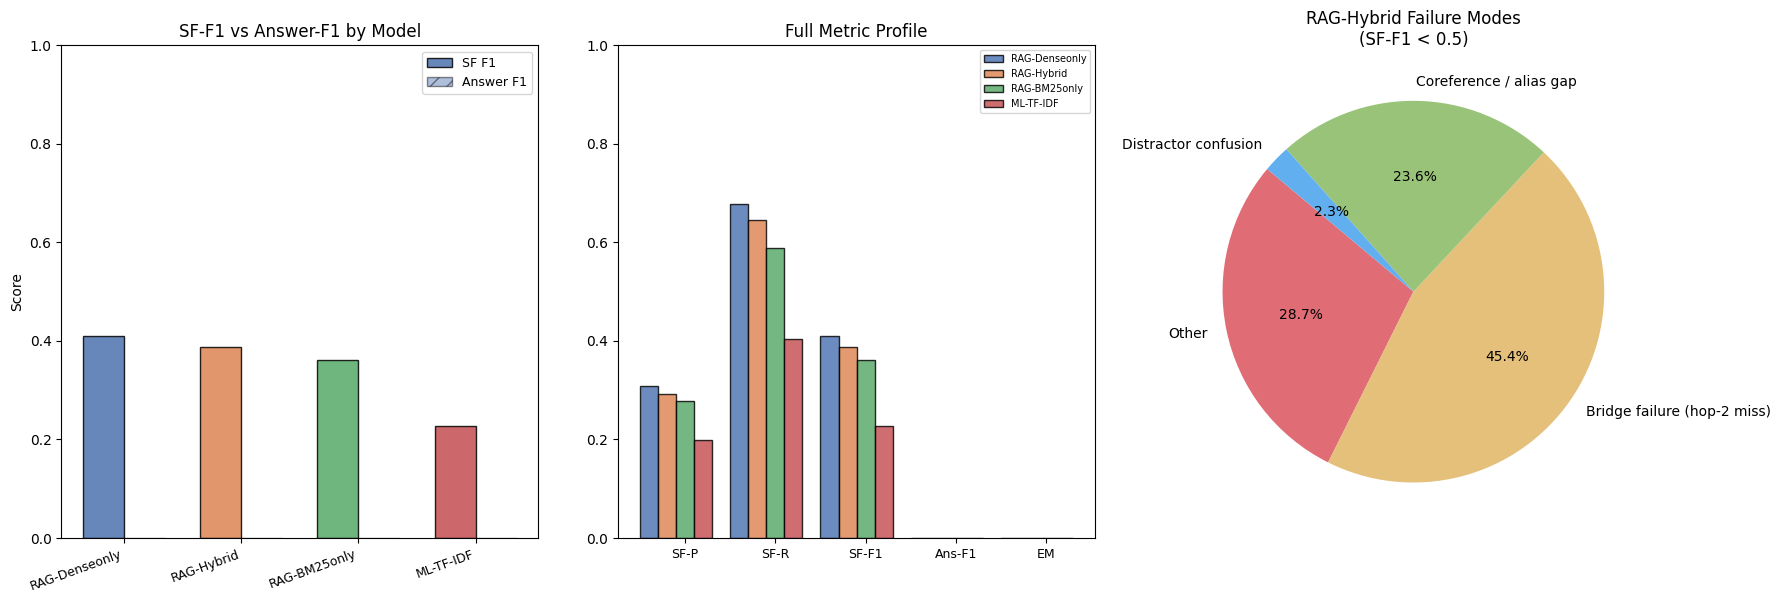

Figure saved to rag_evaluation.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#  A. Supporting-fact F1 bar chart
models   = summary_df.index.tolist()
palette  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
colors   = palette[:len(models)]

x = range(len(models))
w = 0.35
axes[0].bar([i - w/2 for i in x], summary_df["sf_f1"],      width=w,
            color=colors, edgecolor="black", alpha=0.85, label="SF F1")
axes[0].bar([i + w/2 for i in x], summary_df["answer_f1"],  width=w,
            color=colors, edgecolor="black", alpha=0.45, hatch="//", label="Answer F1")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(models, rotation=20, ha="right", fontsize=9)
axes[0].set_title("SF-F1 vs Answer-F1 by Model", fontsize=12)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9)

#  B. Metric profile (radar-style grouped bar)
bar_metrics = ["sf_precision", "sf_recall", "sf_f1", "answer_f1", "em"]
x2 = np.arange(len(bar_metrics))
bar_w = 0.8 / len(models)
for j, (m, c) in enumerate(zip(models, colors)):
    vals = summary_df.loc[m, bar_metrics].values
    axes[1].bar(x2 + j * bar_w - 0.4, vals, width=bar_w,
                label=m, color=c, edgecolor="black", alpha=0.82)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(["SF-P", "SF-R", "SF-F1", "Ans-F1", "EM"], fontsize=9)
axes[1].set_title("Full Metric Profile", fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=7, loc="upper right")

#  C. Failure mode pie (RAG-Hybrid)
if sum(fail_rag.values()) > 0:
    axes[2].pie(
        fail_rag.values(),
        labels=fail_rag.keys(),
        autopct="%1.1f%%",
        startangle=140,
        colors=["#e06c75", "#e5c07b", "#98c379", "#61afef"],
    )
    axes[2].set_title("RAG-Hybrid Failure Modes\n(SF-F1 < 0.5)", fontsize=12)
else:
    axes[2].text(0.5, 0.5, "No failures recorded", ha="center", va="center")
    axes[2].axis("off")

plt.tight_layout()
plt.savefig("rag_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to rag_evaluation.png")

## Focused Error Analysis

Error analysis:   0%|          | 0/50 [00:00<?, ?it/s]

Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma


Low-SF-F1 examples analysed: 43

Root cause distribution:
root_cause
Title found at hop-1 but wrong sentence selected    29
Correct evidence but answer generation error        14

Breakdown by question type:
root_cause  Correct evidence but answer generation error  Title found at hop-1 but wrong sentence selected
q_type                                                                                                    
bridge                                                 7                                                24
comparison                                             7                                                 5


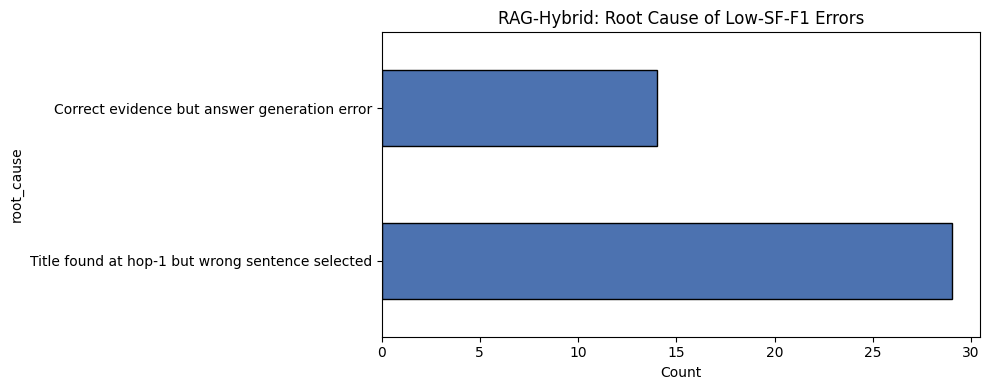

Saved error_analysis.png


In [ ]:
ERROR_SAMPLE = 50   # how many low-SF-F1 examples to re-inspect

error_rows = []

for idx in tqdm(range(min(ERROR_SAMPLE, len(val_ds))), desc="Error analysis"):
    ex       = val_ds[idx]
    q        = ex["question_norm"]
    gold_sf  = list(zip(
        ex["supporting_facts"]["title"],
        [int(s) for s in ex["supporting_facts"]["sent_id"]],
    ))
    gold_ans = ex["answer"]
    gold_titles = {t for t, _ in gold_sf}

    try:
        out = rag_pipeline(q, example_id=ex["id"])
    except Exception:
        continue

    pred_sf  = out["predicted_supporting_facts"]
    pred_ans = out["predicted_answer"]
    diag     = out["retrieval_diagnostics"]

    _, _, sf1 = sf_prf1(pred_sf, gold_sf)
    af1 = answer_f1_score(pred_ans, gold_ans)

    if sf1 >= 0.5:
        continue

    # Hop-1 titles found
    hop1_titles  = set(diag["hop1_titles"])
    hop2_titles  = set(diag["hop2_titles"])
    merged       = set(diag["merged_titles"])
    pred_titles  = {t for t, _ in set(map(tuple, pred_sf))}

    hop1_hit     = bool(gold_titles & hop1_titles)     # ≥1 gold title at hop-1
    hop2_hit     = bool(gold_titles & hop2_titles)     # ≥1 gold title at hop-2
    title_hit    = bool(gold_titles & merged)           # any gold title in final set
    correct_sent = set(map(tuple, pred_sf)) >= set(gold_sf)  # all gold sents retrieved
    ans_correct  = af1 > 0.5

    # Classify root cause
    if not hop1_hit and not hop2_hit:
        root_cause = "Both hops missed gold title"
    elif hop1_hit and not correct_sent:
        root_cause = "Title found at hop-1 but wrong sentence selected"
    elif not hop1_hit and hop2_hit:
        root_cause = "Gold title recovered only at hop-2"
    elif title_hit and not correct_sent:
        root_cause = "Title in merged set but wrong sentence"
    elif correct_sent and not ans_correct:
        root_cause = "Correct evidence but answer generation error"
    else:
        root_cause = "Other"

    error_rows.append({
        "idx"        : idx,
        "question"   : q[:60],
        "q_type"     : ex["type"],
        "sf_f1"      : round(sf1, 3),
        "ans_f1"     : round(af1, 3),
        "hop1_hit"   : hop1_hit,
        "hop2_hit"   : hop2_hit,
        "title_hit"  : title_hit,
        "correct_sent": correct_sent,
        "ans_correct" : ans_correct,
        "root_cause"  : root_cause,
    })

error_df = pd.DataFrame(error_rows)

print(f"\nLow-SF-F1 examples analysed: {len(error_df)}")
if not error_df.empty:
    print("\nRoot cause distribution:")
    rc_counts = error_df["root_cause"].value_counts()
    print(rc_counts.to_string())

    print("\nBreakdown by question type:")
    print(error_df.groupby(["q_type", "root_cause"]).size()
                   .unstack(fill_value=0).to_string())

    # Bar chart of root causes
    fig, ax = plt.subplots(figsize=(10, 4))
    rc_counts.plot(kind="barh", ax=ax, color="#4C72B0", edgecolor="black")
    ax.set_title("RAG-Hybrid: Root Cause of Low-SF-F1 Errors", fontsize=12)
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved error_analysis.png")
else:
    print("No low-SF-F1 examples found in the inspected sample — great!")

## Hyperparameter Tuning Grid

In [ ]:
TUNE_N     = 50   # examples for tuning — fast
tune_rows  = []

for h1 in [3, 5, 7]:
    for h2 in [3, 5]:
        for rn in [4, 6, 8]:
            # Temporarily override CFG values via explicit kwargs
            sf_scores, af_scores = [], []
            for idx in range(TUNE_N):
                ex = val_ds[idx]
                q  = ex["question_norm"]
                gp = list(zip(ex["supporting_facts"]["title"],
                              [int(s) for s in ex["supporting_facts"]["sent_id"]]))
                ga = ex["answer"]
                try:
                    out = rag_pipeline(q, example_id=ex["id"],
                                       hop1_k=h1, hop2_k=h2,
                                       reranker_top_n=rn)
                    _, _, sf1 = sf_prf1(out["predicted_supporting_facts"], gp)
                    af1 = answer_f1_score(out["predicted_answer"], ga)
                    sf_scores.append(sf1)
                    af_scores.append(af1)
                except Exception:
                    pass

            if sf_scores:
                tune_rows.append({
                    "hop1_k"   : h1,
                    "hop2_k"   : h2,
                    "reranker_n": rn,
                    "mean_sf_f1" : np.mean(sf_scores),
                    "mean_ans_f1": np.mean(af_scores),
                })
            print(f"  hop1={h1} hop2={h2} rn={rn} "
                  f"SF-F1={np.mean(sf_scores):.3f} Ans-F1={np.mean(af_scores):.3f}")

tune_df = pd.DataFrame(tune_rows).sort_values("mean_sf_f1", ascending=False)
print("\nTop configurations:")
print(tune_df.head(10).to_string(index=False))

# Apply best config
best_cfg = tune_df.iloc[0]
CFG["hop1_k"]          = int(best_cfg["hop1_k"])
CFG["hop2_k"]          = int(best_cfg["hop2_k"])
CFG["reranker_top_n"]  = int(best_cfg["reranker_n"])
print(f"\nApplied best config: {CFG}")

Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  hop1=3 hop2=3 rn=4 SF-F1=0.470 Ans-F1=0.000


Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  hop1=3 hop2=3 rn=6 SF-F1=0.421 Ans-F1=0.000


Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

...

  hop1=7 hop2=5 rn=4 SF-F1=0.478 Ans-F1=0.000


Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  hop1=7 hop2=5 rn=6 SF-F1=0.406 Ans-F1=0.000


Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

  hop1=7 hop2=5 rn=8 SF-F1=0.356 Ans-F1=0.000

Top configurations:
 hop1_k  hop2_k  reranker_n  mean_sf_f1  mean_ans_f1
      7       3           4    0.478413          0.0
      7       5           4    0.478413          0.0
      5       5           4    0.476571          0.0
      3       3           4    0.470286          0.0
      5       3           4    0.469905          0.0
      3       5           4    0.464571          0.0
      3       3           6    0.421100          0.0
      7       3           6    0.411068          0.0
      7       5           6    0.406068          0.0
      3       3           8    0.401482          0.0

Applied best config: {'val_subset': 200, 'corpus_subset': 500, 'bm25_k': 5, 'dense_k': 5, 'hop1_k': 7, 'hop2_k': 3, 'reranker_top_n': 4, 'reranker_thresh': -5.0, 'max_new_tokens': 64, 'max_evidence_chars': 800, 'embed_model': 'BAAI/bge-small-en-v1.5', 'reranker_model': 'cross-encoder/ms-marco-MiniLM-L-6-v2', 'gen_model': 'google/flan-t5-base', 'ch

In [ ]:
#  1. Final metric table
print("FINAL METRIC TABLE")
final_table = summary_df[["sf_precision", "sf_recall", "sf_f1", "answer_f1", "em"]].copy()
final_table.columns = ["SF-P", "SF-R", "SF-F1", "Ans-F1", "EM"]
print(final_table.round(4).to_string())
print()

# LaTeX export
print("LaTeX:")
print(final_table.round(3).to_latex(bold_rows=True))


#  2. Failure mode counts per model
print("FAILURE MODE COUNTS  (SF-F1 < 0.5 examples)")
for model_name, fail_counter in [
    ("RAG-Hybrid",    fail_rag),
    ("RAG-BM25only",  fail_bm25),
    ("RAG-Denseonly", fail_dense),
]:
    total = sum(fail_counter.values())
    print(f"\n  {model_name}  (total failures: {total})")
    for mode, cnt in fail_counter.most_common():
        pct = 100 * cnt / total if total else 0
        print(f"    {mode:<40s}: {cnt:3d}  ({pct:.1f}%)")


#  3. Worked example
if snap_rag:
    print("WORKED EXAMPLE  (first validation example)")
    def _sep():
        print("-" * 68)

    _sep()
    print("Question:", snap_rag["question"])
    _sep()
    print("Retrieved Evidence (top reranked sentences):")
    print(snap_rag["evidence_text"])
    _sep()
    print("Predicted Answer  :", snap_rag["predicted_answer"])
    print("Gold Answer       :", snap_rag["gold_answer"])
    print(f"  → Answer F1 = {snap_rag['answer_f1']:.4f}   EM = {snap_rag['em']}")
    _sep()
    print("Predicted Supporting Facts:")
    for title, sid in snap_rag["pred_supporting_facts"]:
        print(f"  ({title}, sent {sid})")
    print("Gold Supporting Facts:")
    for title, sid in snap_rag["gold_supporting_facts"]:
        print(f"  ({title}, sent {sid})")
    print(f"  → SF-F1 = {snap_rag['sf_f1']:.4f}")
    _sep()
    diag = snap_rag["retrieval_diagnostics"]
    print("Retrieval Diagnostics:")
    print("  Hop-1 titles  :", diag["hop1_titles"])
    print("  Hop-2 query   :", diag["hop2_query"])
    print("  Hop-2 titles  :", diag["hop2_titles"])
    print("  Merged titles :", diag["merged_titles"])


print("\nAll deliverables produced.")
print("  • rag_evaluation.png  — metric comparison + failure mode chart")
print("  • error_analysis.png  — root-cause breakdown of low-SF-F1 examples")

FINAL METRIC TABLE
                 SF-P    SF-R   SF-F1  Ans-F1   EM
model                                             
RAG-Denseonly  0.3079  0.6787  0.4099     0.0  0.0
RAG-Hybrid     0.2918  0.6453  0.3876     0.0  0.0
RAG-BM25only   0.2772  0.5881  0.3610     0.0  0.0
ML-TF-IDF      0.1994  0.4047  0.2276     0.0  0.0

LaTeX:
\begin{tabular}{lrrrrr}
\toprule
 & SF-P & SF-R & SF-F1 & Ans-F1 & EM \\
model &  &  &  &  &  \\
\midrule
\textbf{RAG-Denseonly} & 0.308000 & 0.679000 & 0.410000 & 0.000000 & 0.000000 \\
\textbf{RAG-Hybrid} & 0.292000 & 0.645000 & 0.388000 & 0.000000 & 0.000000 \\
\textbf{RAG-BM25only} & 0.277000 & 0.588000 & 0.361000 & 0.000000 & 0.000000 \\
\textbf{ML-TF-IDF} & 0.199000 & 0.405000 & 0.228000 & 0.000000 & 0.000000 \\
\bottomrule
\end{tabular}

FAILURE MODE COUNTS  (SF-F1 < 0.5 examples)

  RAG-Hybrid  (total failures: 174)
    Bridge failure (hop-2 miss)             :  79  (45.4%)
    Other                                   :  50  (28.7%)
    Coreference / a